<h1>XGBoost Classifier</h1>
<h2>1.Load Training, Validation, and Test Data</h2>

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_val = pd.read_csv('y_val.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Train: (2117, 5), Validation: (530, 5), Test: (662, 5)


<h2>2.Handle Missing Values and Create New Features</h2>

In [2]:
for df in [X_train, X_val, X_test]:
    df.fillna(df.median(), inplace=True)
    df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
    df['Hour_Day'] = df['Hour'] * df['DayOfWeek']
    df['Hour_squared'] = df['Hour'] ** 2
    df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
    df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)

<h2>3.Feature Scaling (Standardization)</h2>


In [3]:
# Standard Scaling
numeric_cols = ['Hour', 'DayOfWeek']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Combine train and validation for hyperparameter tuning
X_combined = pd.concat([X_train, X_val], axis=0)
y_combined = np.concatenate([y_train, y_val])


<h2>4.Hyperparameter Tuning</h2>


In [4]:
param_dist = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [1, (len(y_combined)-sum(y_combined))/sum(y_combined)],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [3, 5, 7],
    'lambda': [1, 5, 10],
    'alpha': [0, 0.1, 1],
    'max_delta_step': [1, 3, 5],
    'grow_policy': ['depthwise']
}




xgb_clf = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', seed=42)
random_search = RandomizedSearchCV(xgb_clf, param_dist, scoring='f1_macro', n_iter=30, cv=5, n_jobs=-1)
random_search.fit(X_combined, y_combined)
print("Best Hyperparameters:", random_search.best_params_)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                   n_iter=30, n_jobs=-1,
                   param_distributions={'alpha': [0, 0.1, 1],
                                        'colsample_bytree': [0.7, 0.8, 0.9],
                                        'gamma': [0, 0.1, 0.3],
                                        'grow_policy': ['depthwise'],
                                        'lambda': [1, 5, 10],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_delta_step': [1, 3, 5],
                                        'max_depth': [3, 5, 7],
                                        'min_child_weight': [3, 5, 7],
                                        'scale_pos_weight': [1,
                                                             2.2359413202933984],
                                        'subsample': [0.7, 0.8, 0.9]},
                   scoring='f1_macro')

Best Hyperparameters: {'subsample': 0.8, 'scale_pos_weight': 2.2359413202933984, 'min_child_weight': 7, 'max_depth': 3, 'max_delta_step': 3, 'learning_rate': 0.01, 'lambda': 1, 'grow_policy': 'depthwise', 'gamma': 0.1, 'colsample_bytree': 0.9, 'alpha': 1}


<h2>5.Train Model</h2>


In [5]:
# Update best params for xgb.train
best_params = random_search.best_params_
best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'seed': 42,
    'verbosity': 1
})

# Convert to DMatrix
dtrain = xgb.DMatrix(X_combined, label=y_combined)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)
dtrain_only = xgb.DMatrix(X_train, label=y_train)

# Train with Early Stopping
num_boost_round = 500
early_stopping_rounds = 20
evals = [(dtrain_only, 'train'), (dval, 'validation')]

bst = xgb.train(
    best_params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=evals,
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=True
)

print(f"\nBest iteration: {bst.best_iteration}")

[0]	train-logloss:0.69199	validation-logloss:0.69208
[1]	train-logloss:0.69071	validation-logloss:0.69097
[2]	train-logloss:0.68967	validation-logloss:0.69001
[3]	train-logloss:0.68858	validation-logloss:0.68910
[4]	train-logloss:0.68738	validation-logloss:0.68807
[5]	train-logloss:0.68634	validation-logloss:0.68709
[6]	train-logloss:0.68533	validation-logloss:0.68621
[7]	train-logloss:0.68421	validation-logloss:0.68526
[8]	train-logloss:0.68307	validation-logloss:0.68417
[9]	train-logloss:0.68204	validation-logloss:0.68327
[10]	train-logloss:0.68096	validation-logloss:0.68236
[11]	train-logloss:0.67999	validation-logloss:0.68172
[12]	train-logloss:0.67909	validation-logloss:0.68085
[13]	train-logloss:0.67829	validation-logloss:0.68009
[14]	train-logloss:0.67740	validation-logloss:0.67940
[15]	train-logloss:0.67657	validation-logloss:0.67861
[16]	train-logloss:0.67565	validation-logloss:0.67781
[17]	train-logloss:0.67480	validation-logloss:0.67702
[18]	train-logloss:0.67393	validation-

<h2>6.Evaluate Model</h2>


In [6]:
def evaluate_performance(y_true, preds_proba, dataset_name):
    preds = (preds_proba > 0.5).astype(int)
    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average='macro')
    print(f"\n📊 {dataset_name} Performance:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, preds))
    print("Classification Report:\n", classification_report(y_true, preds))

# Predict and Evaluate for each set
train_preds_proba = bst.predict(dtrain_only, iteration_range=(0, bst.best_iteration))
evaluate_performance(y_train, train_preds_proba, "Train Set")

val_preds_proba = bst.predict(dval, iteration_range=(0, bst.best_iteration))
evaluate_performance(y_val, val_preds_proba, "Validation Set")

test_preds_proba = bst.predict(dtest, iteration_range=(0, bst.best_iteration))
evaluate_performance(y_test, test_preds_proba, "Test Set")



📊 Train Set Performance:
Accuracy: 0.7005
Macro F1: 0.6669
Confusion Matrix:
 [[1078  385]
 [ 249  405]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.74      0.77      1463
           1       0.51      0.62      0.56       654

    accuracy                           0.70      2117
   macro avg       0.66      0.68      0.67      2117
weighted avg       0.72      0.70      0.71      2117


📊 Validation Set Performance:
Accuracy: 0.6925
Macro F1: 0.6498
Confusion Matrix:
 [[276  90]
 [ 73  91]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77       366
           1       0.50      0.55      0.53       164

    accuracy                           0.69       530
   macro avg       0.65      0.65      0.65       530
weighted avg       0.70      0.69      0.70       530


📊 Test Set Performance:
Accuracy: 0.7009
Macro F1: 0.6653
Confusion Matrix:
 [[340 1

<h2>7..Confusion Matrix</h2>


<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Test Set - Confusion Matrix')

Text(0.5, 14.722222222222216, 'Predicted Label')

Text(33.22222222222222, 0.5, 'True Label')

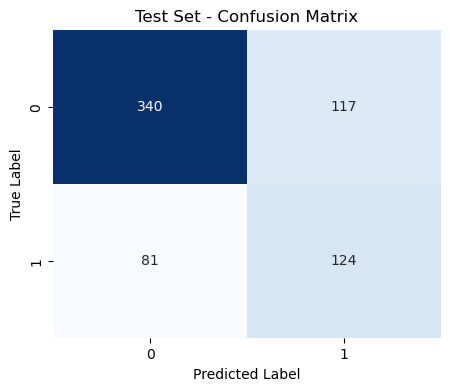

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_preds = (test_preds_proba > 0.5).astype(int)
cm_test = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Test Set - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



<h2>9.Test Set - ROC Curve</h2>


<Figure size 600x500 with 0 Axes>

(0.0, 1.0)

(0.0, 1.05)

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'Test Set - ROC Curve')

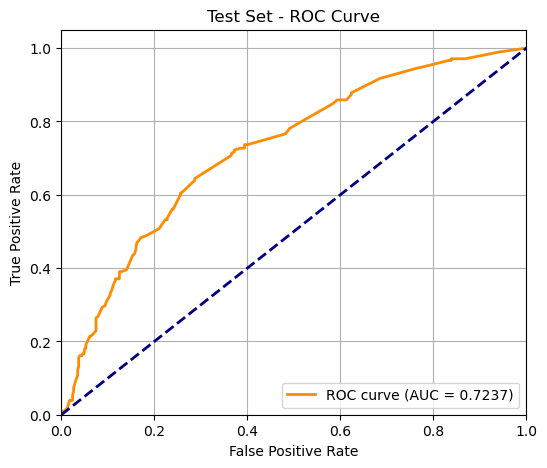

In [8]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, test_preds_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test Set - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
